# HIICNN — Hybrid Image-Improving and CNN Stacking Ensemble for Traffic Sign Recognition

A GPU-accelerated pipeline for the GTSRB benchmark (43 German traffic sign
classes) combining classical image-enhancement preprocessing with a
stacking ensemble of three ImageNet-pretrained CNN backbones — **ResNet50**,
**VGG16**, and **EfficientNetB0** — fused by a learned meta-learner, with
latency/FPS reporting to support a real-time autonomous-driving framing.

**Pipeline:** enhance → resize/normalize → 3 backbones → concat softmax
outputs → meta-learner → final prediction.

**Expected dataset layout** (already downloaded, Kaggle-style GTSRB), next
to this notebook:

```
data/
├── Train/                # per-class subfolders (0..42)
├── Test/                 # flat folder of test images
├── Meta/
├── Train.csv             # Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
├── Test.csv
└── Meta.csv
```

Run the cells top to bottom. Training is the slow step — reduce
`NUM_EPOCHS` below for a quick smoke test before a full run.


> **Changes vs. the original version, and why**
> 1. **Partial backbone fine-tuning** (`FINE_TUNE_LAST_BLOCK`): each backbone's *last* block is
>    unfrozen and trained at a small `BACKBONE_LR`, on top of the head at `HEAD_LR`. Fully-frozen
>    ImageNet features were capping every backbone at ~50% — they were never adapted to the
>    traffic-sign domain.
> 2. **Mini-batch meta-learner training with a held-out meta-val split**: the old version did one
>    full-batch gradient step per "epoch" with no way to tell whether it had converged. It plateaued
>    at ~47% train accuracy — *below* the naive-average baseline it should have been able to match.
>    It now trains in real mini-batches, uses `AdamW` + cosine LR decay, and keeps the checkpoint
>    with the best score on data it wasn't trained on.
> 3. **Class-weighted sampling** (`USE_WEIGHTED_SAMPLER`): GTSRB is heavily imbalanced across its
>    43 classes; without this, rare signs are effectively ignored and macro precision/recall/F1 suffer.
> 4. **Early stopping, label smoothing, mixed precision, AdamW**: lets you afford more epochs
>    (`NUM_EPOCHS = 25`) without it costing much extra wall-clock time or overfitting.
> 5. **Slightly larger `IMAGE_SIZE` (112 vs 96)** to keep a bit more detail on small, cropped signs.

## Imports


In [1]:
import os
import time
import json

import numpy as np
import pandas as pd
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms, models

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

import matplotlib.pyplot as plt
%matplotlib inline

from tqdm.auto import tqdm

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Laptop GPU


c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Edit these values to change dataset paths, image size, training hyperparameters, or which backbones are used.


In [2]:
# ---------------------------------------------------------------------------
# Paths — assumes this notebook lives at the project root, next to your
# already-downloaded data/ folder (Train/, Test/, Train.csv, Test.csv).
# ---------------------------------------------------------------------------
PROJECT_ROOT = os.getcwd()
DATA_ROOT = os.path.join(PROJECT_ROOT, "data")
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints_improved")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results_improved")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# Device
# ---------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------------------------
# Dataset
# ---------------------------------------------------------------------------
NUM_CLASSES = 43
IMAGE_SIZE = 112          # bumped from 96: small signs keep more usable detail
VAL_SPLIT = 0.1           # held out from Train.csv: used to monitor backbone
                          # training AND to generate the meta-learner's
                          # training data (proper stacking).
SEED = 42

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

USE_WEIGHTED_SAMPLER = True   # counters GTSRB's heavy per-class imbalance

# ---------------------------------------------------------------------------
# Image enhancement stage
# ---------------------------------------------------------------------------
USE_SHARPENING = True
USE_UNSHARP_MASK = True
USE_CLAHE_CONTRAST = True

# ---------------------------------------------------------------------------
# Backbones used in the stacking ensemble
# ---------------------------------------------------------------------------
BACKBONES = ["resnet50", "vgg16", "efficientnet_b0"]

# Instead of a single FREEZE_BACKBONE on/off switch, each backbone now
# fine-tunes its LAST block while keeping the earlier, general-purpose
# layers frozen. This matters a lot here: ImageNet photographs are a very
# different domain from small, tightly-cropped traffic-sign icons, so a
# fully-frozen backbone plateaus around ~50% no matter how long you train
# just the head — the frozen features simply don't encode what separates
# a "30 km/h" sign from a "50 km/h" sign.
FINE_TUNE_LAST_BLOCK = True

# ---------------------------------------------------------------------------
# Training hyperparameters
# ---------------------------------------------------------------------------
BATCH_SIZE = 64
NUM_EPOCHS = 25            # early stopping below will usually cut this short
HEAD_LR = 1e-3             # LR for the newly-added classifier head
BACKBONE_LR = 1e-5         # much smaller LR for the unfrozen backbone layers —
                           # fine-tuning pretrained weights too fast destroys them
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
NUM_WORKERS = 0
EARLY_STOP_PATIENCE = 6    # stop a backbone if val_acc stalls this many epochs
USE_AMP = torch.cuda.is_available()   # mixed precision on GPU: ~2x faster,
                                       # which is what buys us the extra epochs

# Meta-learner (stacking head)
META_HIDDEN_DIM = 128
META_EPOCHS = 200
META_BATCH_SIZE = 128
META_LR = 3e-4
META_WEIGHT_DECAY = 1e-3
META_VAL_FRACTION = 0.2    # carved off the val split to early-stop the meta-learner
                           # on data it wasn't trained on (the old version had
                           # no way to detect it was stuck — this fixes that)

print(f"Using device: {DEVICE}")


Using device: cuda


## 1. Image Enhancement Stage

Three classical techniques, chained in this order, before resizing:

1. **CLAHE contrast enhancement** — adaptive histogram equalization on the
   L-channel of LAB space, to recover detail in over/under-exposed signs.
2. **Unsharp masking** — Gaussian-blur, subtract from the original, add
   back — boosts overall edge contrast.
3. **Sharpening convolution kernel** — a cheap 3x3 kernel for a final
   edge-emphasis pass, cheap enough to run per-frame in a real-time system.


In [3]:
def apply_clahe_contrast(img, clip_limit=2.0, tile_grid_size=(8, 8)):
    """Contrast Limited Adaptive Histogram Equalization on the L channel of LAB space."""
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_eq = clahe.apply(l)
    lab_eq = cv2.merge((l_eq, a, b))
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)


def apply_unsharp_mask(img, sigma=1.0, amount=1.5, threshold=0):
    """Classic unsharp masking: sharpened = original + amount * (original - blurred)."""
    blurred = cv2.GaussianBlur(img, (0, 0), sigma)
    sharpened = cv2.addWeighted(img, 1 + amount, blurred, -amount, 0)
    if threshold > 0:
        low_contrast_mask = np.abs(img.astype(int) - blurred.astype(int)) < threshold
        sharpened = np.where(low_contrast_mask, img, sharpened)
    return np.clip(sharpened, 0, 255).astype(np.uint8)


def apply_sharpening_kernel(img):
    """Edge-emphasizing 3x3 sharpening convolution kernel."""
    kernel = np.array([[0, -1, 0],
                        [-1, 5, -1],
                        [0, -1, 0]], dtype=np.float32)
    sharpened = cv2.filter2D(img, -1, kernel)
    return np.clip(sharpened, 0, 255).astype(np.uint8)


def enhance_image(img):
    """Full classical enhancement pipeline applied to a single RGB uint8 image."""
    out = img
    if USE_CLAHE_CONTRAST:
        out = apply_clahe_contrast(out)
    if USE_UNSHARP_MASK:
        out = apply_unsharp_mask(out)
    if USE_SHARPENING:
        out = apply_sharpening_kernel(out)
    return out


class EnhancementTransform:
    """Torchvision-compatible transform: PIL.Image -> enhanced PIL.Image."""

    def __call__(self, pil_img):
        arr = np.array(pil_img.convert("RGB"))
        enhanced = enhance_image(arr)
        return Image.fromarray(enhanced)


## 2. Dataset (Kaggle GTSRB CSV layout)


In [4]:
def _find_csv_columns(df):
    """Kaggle GTSRB CSVs consistently use
    Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path — tolerant of
    minor casing differences across mirrors."""
    cols = {c.lower(): c for c in df.columns}
    for required in ("path", "classid"):
        if required not in cols:
            raise ValueError(f"Expected a '{required}' column in the GTSRB csv, got columns: {list(df.columns)}")
    roi_names = ["roi.x1", "roi.y1", "roi.x2", "roi.y2"]
    roi_cols = [cols[r] for r in roi_names] if all(r in cols for r in roi_names) else None
    return cols["path"], cols["classid"], roi_cols


class GTSRBCSVDataset(Dataset):
    """Reads Train.csv or Test.csv and loads the corresponding images
    from disk, cropping to the annotated ROI when the columns are present."""

    def __init__(self, root, csv_name, transform=None):
        self.root = root
        self.transform = transform
        csv_path = os.path.join(root, csv_name)
        if not os.path.exists(csv_path):
            raise FileNotFoundError(
                f"Could not find {csv_path}.\n"
                f"Expected the Kaggle GTSRB layout under DATA_ROOT ({root}):\n"
                f"  Train.csv, Test.csv, Train/<classid>/*.png, Test/*.png"
            )
        df = pd.read_csv(csv_path)
        self.path_col, self.class_col, self.roi_cols = _find_csv_columns(df)
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root, row[self.path_col])
        img = Image.open(img_path).convert("RGB")
        if self.roi_cols is not None:
            x1, y1, x2, y2 = (int(row[c]) for c in self.roi_cols)
            img = img.crop((x1, y1, x2, y2))
        label = int(row[self.class_col])
        if self.transform is not None:
            img = self.transform(img)
        return img, label


def build_transforms(train=True):
    ops = [EnhancementTransform()]
    if train:
        ops += [
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
        ]
    ops += [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
    return transforms.Compose(ops)


def get_datasets():
    """Returns (train_ds, val_ds, test_ds). val_ds is carved out of
    Train.csv (not augmented) and is used both to monitor backbone
    training and to generate the meta-learner's training data."""
    train_tf = build_transforms(train=True)
    eval_tf = build_transforms(train=False)

    full_train_aug = GTSRBCSVDataset(DATA_ROOT, "Train.csv", transform=train_tf)
    full_train_eval = GTSRBCSVDataset(DATA_ROOT, "Train.csv", transform=eval_tf)

    n_total = len(full_train_aug)
    n_val = int(n_total * VAL_SPLIT)
    n_train = n_total - n_val

    generator = torch.Generator().manual_seed(SEED)
    train_subset, val_subset_idx = random_split(full_train_aug, [n_train, n_val], generator=generator)
    val_indices = val_subset_idx.indices
    val_subset = Subset(full_train_eval, val_indices)

    test_ds = GTSRBCSVDataset(DATA_ROOT, "Test.csv", transform=eval_tf)
    return train_subset, val_subset, test_ds


def get_dataloaders():
    train_ds, val_ds, test_ds = get_datasets()
    pin = DEVICE.type == "cuda"

    if USE_WEIGHTED_SAMPLER:
        # GTSRB is heavily imbalanced (e.g. common speed-limit signs have
        # ~10x more examples than some rare warning signs). Left uncorrected,
        # models mostly ignore rare classes, which quietly drags down macro
        # precision/recall/F1 even when raw accuracy looks fine.
        base_ds = train_ds.dataset  # underlying GTSRBCSVDataset (train_ds is a Subset)
        subset_labels = base_ds.df[base_ds.class_col].values[train_ds.indices]
        class_counts = np.bincount(subset_labels, minlength=NUM_CLASSES)
        class_weights = 1.0 / np.clip(class_counts, 1, None)
        sample_weights = class_weights[subset_labels]
        sampler = torch.utils.data.WeightedRandomSampler(
            weights=torch.as_tensor(sample_weights, dtype=torch.double),
            num_samples=len(sample_weights),
            replacement=True,
        )
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                                   num_workers=NUM_WORKERS, pin_memory=pin)
    else:
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                                   num_workers=NUM_WORKERS, pin_memory=pin)

    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)
    return train_loader, val_loader, test_loader


### Sanity check: raw vs. enhanced sample image


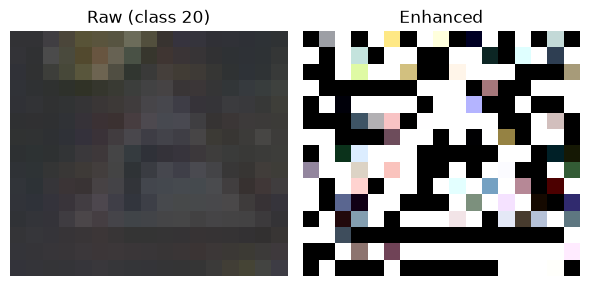

In [5]:
_demo_ds = GTSRBCSVDataset(DATA_ROOT, "Train.csv", transform=None)
_raw_img, _label = _demo_ds[0]
_enhanced_img = EnhancementTransform()(_raw_img)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(_raw_img); axes[0].set_title(f"Raw (class {_label})"); axes[0].axis("off")
axes[1].imshow(_enhanced_img); axes[1].set_title("Enhanced"); axes[1].axis("off")
plt.tight_layout()
plt.show()


## 3. Base models (ResNet50, VGG16, EfficientNetB0) + stacking meta-learner


In [6]:
def _freeze(module):
    for p in module.parameters():
        p.requires_grad = False


def _unfreeze(module):
    for p in module.parameters():
        p.requires_grad = True


def build_resnet50(num_classes=NUM_CLASSES, fine_tune_last_block=FINE_TUNE_LAST_BLOCK):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    _freeze(model)
    if fine_tune_last_block:
        _unfreeze(model.layer4)   # last residual stage: the domain-specific features
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )
    return model  # model.fc is freshly created, so always trainable


def build_vgg16(num_classes=NUM_CLASSES, fine_tune_last_block=FINE_TUNE_LAST_BLOCK):
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    _freeze(model.features)
    if fine_tune_last_block:
        _unfreeze(model.features[24:])   # last conv block (conv5_x)
    in_features = model.classifier[6].in_features
    model.classifier[6] = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )
    return model


def build_efficientnet_b0(num_classes=NUM_CLASSES, fine_tune_last_block=FINE_TUNE_LAST_BLOCK):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    _freeze(model.features)
    if fine_tune_last_block:
        _unfreeze(model.features[-2:])   # last MBConv stage + final 1x1 conv
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )
    return model


BACKBONE_BUILDERS = {
    "resnet50": build_resnet50,
    "vgg16": build_vgg16,
    "efficientnet_b0": build_efficientnet_b0,
}

# Which submodule holds each backbone's "new head", so the optimizer can
# give it a bigger learning rate than the fine-tuned backbone layers.
HEAD_ATTR = {
    "resnet50": "fc",
    "vgg16": "classifier",
    "efficientnet_b0": "classifier",
}


def build_backbone(name, num_classes=NUM_CLASSES, fine_tune_last_block=FINE_TUNE_LAST_BLOCK):
    if name not in BACKBONE_BUILDERS:
        raise ValueError(f"Unknown backbone '{name}'. Options: {list(BACKBONE_BUILDERS)}")
    return BACKBONE_BUILDERS[name](num_classes=num_classes, fine_tune_last_block=fine_tune_last_block)


def get_param_groups(model, name):
    """Head params train at HEAD_LR; any unfrozen backbone params train at
    the much smaller BACKBONE_LR. Frozen params are excluded entirely."""
    head_module = getattr(model, HEAD_ATTR[name])
    head_param_ids = set(id(p) for p in head_module.parameters())
    head, backbone = [], []
    for p in model.parameters():
        if not p.requires_grad:
            continue
        (head if id(p) in head_param_ids else backbone).append(p)
    groups = [{"params": head, "lr": HEAD_LR}]
    if backbone:
        groups.append({"params": backbone, "lr": BACKBONE_LR})
    return groups


class MetaLearner(nn.Module):
    """Small MLP stacking head: takes the concatenated softmax outputs of
    all base models and learns to weight/combine them into the final
    43-class prediction."""

    def __init__(self, num_backbones=len(BACKBONES), num_classes=NUM_CLASSES, hidden_dim=META_HIDDEN_DIM):
        super().__init__()
        in_dim = num_backbones * num_classes
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, x):
        return self.net(x)


## 4. Training functions


In [7]:
def train_one_backbone(name, train_loader, val_loader):
    print(f"\n{'='*60}\nTraining backbone: {name}\n{'='*60}")
    model = build_backbone(name).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

    param_groups = get_param_groups(model, name)
    optimizer = optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    best_val_acc = 0.0
    epochs_without_improvement = 0
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"{name}.pt")

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss, running_correct, n = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f"[{name}] epoch {epoch+1}/{NUM_EPOCHS}")
        for imgs, labels in pbar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * imgs.size(0)
            running_correct += (outputs.argmax(1) == labels).sum().item()
            n += imgs.size(0)
            pbar.set_postfix(loss=running_loss / n, acc=running_correct / n)

        val_acc = evaluate_accuracy(model, val_loader)
        scheduler.step(val_acc)
        print(f"[{name}] epoch {epoch+1}: train_acc={running_correct/n:.4f}  val_acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_without_improvement = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f"  -> new best ({val_acc:.4f}), saved to {ckpt_path}")
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= EARLY_STOP_PATIENCE:
                print(f"  -> no improvement for {EARLY_STOP_PATIENCE} epochs, stopping early.")
                break

    print(f"Finished {name}. Best val acc: {best_val_acc:.4f}")
    return ckpt_path


@torch.no_grad()
def evaluate_accuracy(model, loader):
    model.eval()
    correct, n = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        correct += (outputs.argmax(1) == labels).sum().item()
        n += imgs.size(0)
    return correct / n


@torch.no_grad()
def get_softmax_predictions(model, loader):
    """Runs a backbone over a loader and returns (probs, labels) as numpy arrays."""
    model.eval()
    all_probs, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)


def train_meta_learner(val_loader):
    """Builds the meta-learner's training data from the held-out val split,
    then splits THAT again into a meta-train/meta-val slice so the
    meta-learner can be trained with real mini-batches and early-stopped on
    data it wasn't fit on. The previous version did one full-batch gradient
    step per "epoch" with no way to tell whether it had converged or was
    stuck — that's why it plateaued at ~47% train accuracy, below even the
    naive-average baseline it should have been able to match or beat."""
    print(f"\n{'='*60}\nTraining stacking meta-learner\n{'='*60}")
    backbone_probs = []
    labels = None
    for name in BACKBONES:
        model = build_backbone(name).to(DEVICE)
        model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, f"{name}.pt"), map_location=DEVICE))
        probs, lbls = get_softmax_predictions(model, val_loader)
        backbone_probs.append(probs)
        labels = lbls

    stacked_features = np.concatenate(backbone_probs, axis=1)

    # Split the val-derived features into meta-train / meta-val so we can
    # actually detect overfitting instead of guessing.
    n_total = len(labels)
    rng = np.random.default_rng(SEED)
    idx = rng.permutation(n_total)
    n_meta_val = int(n_total * META_VAL_FRACTION)
    val_idx, train_idx = idx[:n_meta_val], idx[n_meta_val:]

    X_train = torch.tensor(stacked_features[train_idx], dtype=torch.float32)
    y_train = torch.tensor(labels[train_idx], dtype=torch.long)
    X_val = torch.tensor(stacked_features[val_idx], dtype=torch.float32).to(DEVICE)
    y_val = torch.tensor(labels[val_idx], dtype=torch.long).to(DEVICE)

    meta_train_ds = torch.utils.data.TensorDataset(X_train, y_train)
    meta_train_loader = DataLoader(meta_train_ds, batch_size=META_BATCH_SIZE, shuffle=True)

    meta = MetaLearner().to(DEVICE)
    optimizer = optim.AdamW(meta.parameters(), lr=META_LR, weight_decay=META_WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=META_EPOCHS)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

    best_val_acc = 0.0
    ckpt_path = os.path.join(CHECKPOINT_DIR, "meta_learner.pt")

    for epoch in range(META_EPOCHS):
        meta.train()
        last_loss = None
        for xb, yb in meta_train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = meta(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            last_loss = loss.item()
        scheduler.step()

        meta.eval()
        with torch.no_grad():
            val_out = meta(X_val)
            val_acc = (val_out.argmax(1) == y_val).float().mean().item()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(meta.state_dict(), ckpt_path)

        if (epoch + 1) % 10 == 0:
            print(f"  meta epoch {epoch+1}/{META_EPOCHS}  loss={last_loss:.4f}  "
                  f"meta_val_acc={val_acc:.4f}  best={best_val_acc:.4f}")

    print(f"Meta-learner saved to {ckpt_path} (best meta-val acc: {best_val_acc:.4f})")


## Run: build the dataloaders


In [8]:
train_loader, val_loader, test_loader = get_dataloaders()
print(f"train: {len(train_loader.dataset)}  val: {len(val_loader.dataset)}  test: {len(test_loader.dataset)}")


train: 35289  val: 3920  test: 12630


## Run: train all three backbones

This is the slow step. With a GPU this takes a while depending on
`NUM_EPOCHS`; on CPU it will be very slow — reduce `NUM_EPOCHS` in the
config cell above for a quick smoke test first.


In [9]:
for _name in BACKBONES:
    train_one_backbone(_name, train_loader, val_loader)



Training backbone: resnet50


C:\Users\Mohammed Elidrissi\AppData\Local\Temp\ipykernel_24764\2443031239.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
[resnet50] epoch 1/25: 100%|██████████| 552/552 [01:16<00:00,  7.18it/s, acc=0.385, loss=2.27]


[resnet50] epoch 1: train_acc=0.3847  val_acc=0.5173
  -> new best (0.5173), saved to c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\checkpoints_improved\resnet50.pt


[resnet50] epoch 2/25: 100%|██████████| 552/552 [01:21<00:00,  6.81it/s, acc=0.578, loss=1.64]


[resnet50] epoch 2: train_acc=0.5780  val_acc=0.6133
  -> new best (0.6133), saved to c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\checkpoints_improved\resnet50.pt


...

[efficientnet_b0] epoch 23: train_acc=0.6346  val_acc=0.6763
  -> new best (0.6763), saved to c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\checkpoints_improved\efficientnet_b0.pt


[efficientnet_b0] epoch 24/25: 100%|██████████| 552/552 [01:38<00:00,  5.63it/s, acc=0.641, loss=1.46]


[efficientnet_b0] epoch 24: train_acc=0.6410  val_acc=0.6689


[efficientnet_b0] epoch 25/25: 100%|██████████| 552/552 [01:38<00:00,  5.62it/s, acc=0.643, loss=1.45]


[efficientnet_b0] epoch 25: train_acc=0.6435  val_acc=0.6855
  -> new best (0.6855), saved to c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\checkpoints_improved\efficientnet_b0.pt
Finished efficientnet_b0. Best val acc: 0.6855


## Run: train the stacking meta-learner


In [10]:
train_meta_learner(val_loader)



Training stacking meta-learner
  meta epoch 10/200  loss=0.9715  meta_val_acc=0.9082  best=0.9082
  meta epoch 20/200  loss=0.7023  meta_val_acc=0.9337  best=0.9337
  meta epoch 30/200  loss=0.6238  meta_val_acc=0.9337  best=0.9349
  meta epoch 40/200  loss=0.6278  meta_val_acc=0.9311  best=0.9349
  meta epoch 50/200  loss=0.6813  meta_val_acc=0.9286  best=0.9349
  meta epoch 60/200  loss=0.6239  meta_val_acc=0.9311  best=0.9349
  meta epoch 70/200  loss=0.5932  meta_val_acc=0.9298  best=0.9349
  meta epoch 80/200  loss=0.5506  meta_val_acc=0.9337  best=0.9349
  meta epoch 90/200  loss=0.5467  meta_val_acc=0.9349  best=0.9349
  meta epoch 100/200  loss=0.6706  meta_val_acc=0.9337  best=0.9349
  meta epoch 110/200  loss=0.5416  meta_val_acc=0.9324  best=0.9349
  meta epoch 120/200  loss=0.6332  meta_val_acc=0.9311  best=0.9349
  meta epoch 130/200  loss=0.4898  meta_val_acc=0.9324  best=0.9349
  meta epoch 140/200  loss=0.5893  meta_val_acc=0.9311  best=0.9349
  meta epoch 150/200  los

## 5. Evaluation — accuracy / precision / recall / F1 / confusion matrices


In [11]:
def load_trained_backbone(name, required=True):
    model = build_backbone(name).to(DEVICE)
    ckpt = os.path.join(CHECKPOINT_DIR, f"{name}.pt")
    if os.path.exists(ckpt):
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    elif required:
        raise FileNotFoundError(f"No checkpoint found for '{name}' at {ckpt}. Train it first.")
    model.eval()
    return model


def load_meta_learner(required=True):
    meta = MetaLearner().to(DEVICE)
    ckpt = os.path.join(CHECKPOINT_DIR, "meta_learner.pt")
    if os.path.exists(ckpt):
        meta.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    elif required:
        raise FileNotFoundError(f"No meta-learner checkpoint found at {ckpt}. Train it first.")
    meta.eval()
    return meta


def compute_metrics(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    print(f"\n--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    return {"model": name, "accuracy": acc, "precision": precision, "recall": recall, "f1": f1}


def plot_confusion_matrix(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 10))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    out_path = os.path.join(RESULTS_DIR, f"confusion_matrix_{name}.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved confusion matrix to {out_path}")


## Run: full evaluation on the GTSRB test set



--- resnet50 ---
Accuracy:  0.8193
Precision: 0.7766
Recall:    0.7802
F1-score:  0.7725


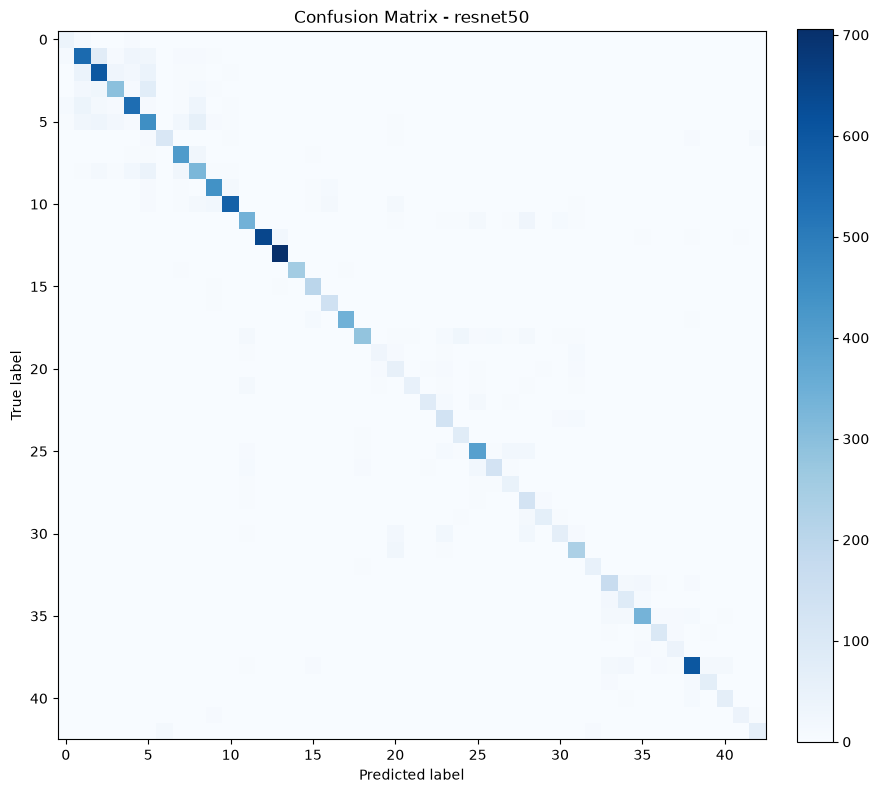

Saved confusion matrix to c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\results_improved\confusion_matrix_resnet50.png

--- vgg16 ---
Accuracy:  0.8138
Precision: 0.7944
Recall:    0.7724
F1-score:  0.7756


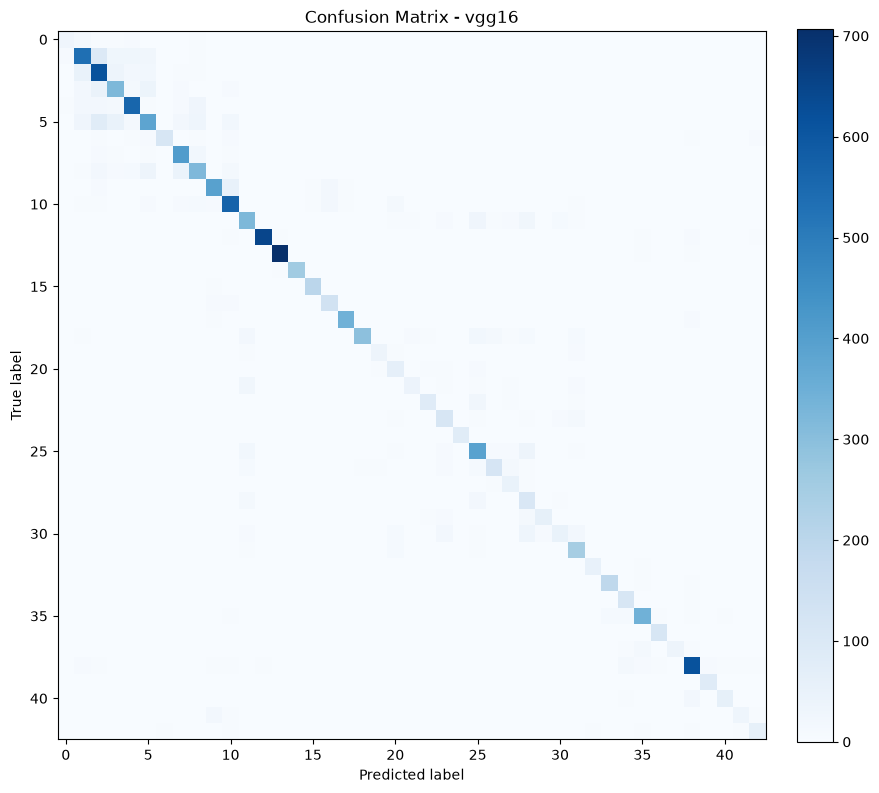

Saved confusion matrix to c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\results_improved\confusion_matrix_vgg16.png

--- efficientnet_b0 ---
Accuracy:  0.5639
Precision: 0.4940
Recall:    0.5371
F1-score:  0.5008


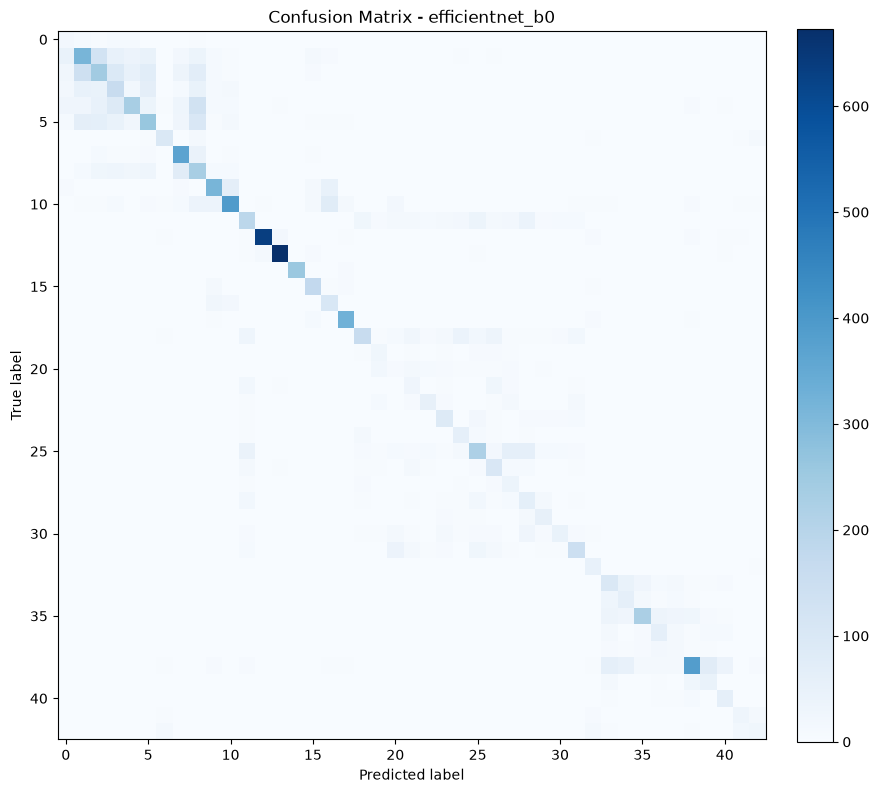

Saved confusion matrix to c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\results_improved\confusion_matrix_efficientnet_b0.png

--- HIICNN_stacking_ensemble ---
Accuracy:  0.8621
Precision: 0.8505
Recall:    0.8192
F1-score:  0.8292


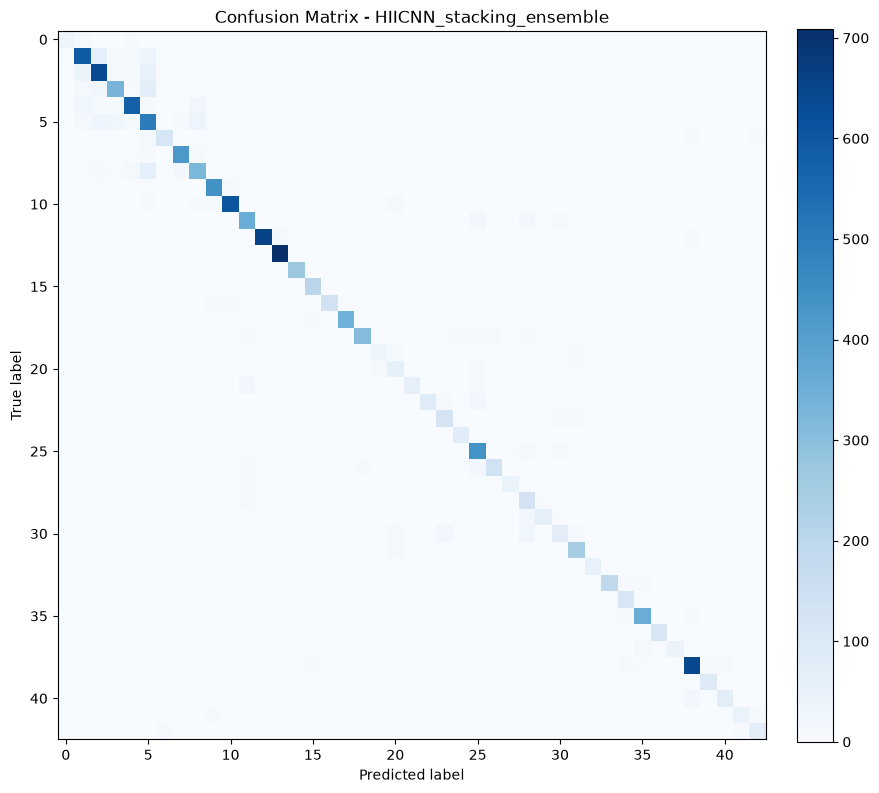

Saved confusion matrix to c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\results_improved\confusion_matrix_HIICNN_stacking_ensemble.png

--- naive_average_ensemble ---
Accuracy:  0.8554
Precision: 0.8230
Recall:    0.8176
F1-score:  0.8149

Comparison table saved to c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\results_improved\comparison_table.json

Model                          Accuracy  Precision     Recall         F1
resnet50                         0.8193     0.7766     0.7802     0.7725
vgg16                            0.8138     0.7944     0.7724     0.7756
efficientnet_b0                  0.5639     0.4940     0.5371     0.5008
HIICNN_stacking_ensemble         0.8621     0.8505     0.8192     0.8292
naive_average_ensemble           0.8554     0.8230     0.8176     0.8149


In [12]:
all_results = []
backbone_probs = {}
y_true = None

for _name in BACKBONES:
    _model = load_trained_backbone(_name)
    probs, labels = get_softmax_predictions(_model, test_loader)
    backbone_probs[_name] = probs
    y_true = labels
    y_pred = probs.argmax(axis=1)
    all_results.append(compute_metrics(y_true, y_pred, _name))
    plot_confusion_matrix(y_true, y_pred, _name)

# HIICNN stacking ensemble (trained meta-learner)
stacked = np.concatenate([backbone_probs[_name] for _name in BACKBONES], axis=1)
meta = load_meta_learner()
with torch.no_grad():
    X = torch.tensor(stacked, dtype=torch.float32).to(DEVICE)
    y_pred_ensemble = meta(X).argmax(1).cpu().numpy()

all_results.append(compute_metrics(y_true, y_pred_ensemble, "HIICNN_stacking_ensemble"))
plot_confusion_matrix(y_true, y_pred_ensemble, "HIICNN_stacking_ensemble")

# Naive-average ensemble, reported as a baseline the stacking meta-learner should beat
avg_probs = np.mean([backbone_probs[_name] for _name in BACKBONES], axis=0)
y_pred_avg = avg_probs.argmax(axis=1)
all_results.append(compute_metrics(y_true, y_pred_avg, "naive_average_ensemble"))

results_path = os.path.join(RESULTS_DIR, "comparison_table.json")
with open(results_path, "w") as f:
    json.dump(all_results, f, indent=2)
print(f"\nComparison table saved to {results_path}")

print("\n{:<28} {:>10} {:>10} {:>10} {:>10}".format("Model", "Accuracy", "Precision", "Recall", "F1"))
for r in all_results:
    print("{:<28} {:>10.4f} {:>10.4f} {:>10.4f} {:>10.4f}".format(
        r["model"], r["accuracy"], r["precision"], r["recall"], r["f1"]))


## 6. Real-time framing — inference latency (ms/image) and FPS


In [13]:
@torch.no_grad()
def benchmark_model(model, input_shape, n_warmup=20, n_runs=200, batch_size=1):
    model.eval()
    dummy = torch.randn(batch_size, *input_shape).to(DEVICE)

    for _ in range(n_warmup):
        _ = model(dummy)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()
    for _ in range(n_runs):
        _ = model(dummy)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    ms_per_image = (elapsed / n_runs / batch_size) * 1000
    fps = 1000 / ms_per_image
    return ms_per_image, fps


class EnsembleWrapper(nn.Module):
    """Wraps the three backbones + meta-learner into a single forward
    pass, so the whole HIICNN pipeline's latency can be measured
    end-to-end, the way it would run in a deployed system."""

    def __init__(self, backbones, meta):
        super().__init__()
        self.backbones = nn.ModuleList(backbones)
        self.meta = meta

    def forward(self, x):
        probs = [torch.softmax(b(x), dim=1) for b in self.backbones]
        stacked = torch.cat(probs, dim=1)
        return self.meta(stacked)


## Run: benchmark latency and FPS


In [14]:
if DEVICE.type != "cuda":
    print("WARNING: no CUDA GPU detected — these numbers won't reflect the "
          "real-time GPU-inference framing.")

input_shape = (3, IMAGE_SIZE, IMAGE_SIZE)
bench_results = []
bench_backbones = []

for _name in BACKBONES:
    _model = load_trained_backbone(_name, required=False)
    bench_backbones.append(_model)
    ms, fps = benchmark_model(_model, input_shape)
    print(f"{_name:>18}: {ms:6.2f} ms/image  |  {fps:7.1f} FPS")
    bench_results.append({"model": _name, "ms_per_image": ms, "fps": fps})

_meta = load_meta_learner(required=False)
_ensemble = EnsembleWrapper(bench_backbones, _meta).to(DEVICE)
ms, fps = benchmark_model(_ensemble, input_shape)
print(f"{'HIICNN ensemble':>18}: {ms:6.2f} ms/image  |  {fps:7.1f} FPS")
bench_results.append({"model": "HIICNN_stacking_ensemble", "ms_per_image": ms, "fps": fps})

bench_path = os.path.join(RESULTS_DIR, "latency_benchmark.json")
with open(bench_path, "w") as f:
    json.dump(bench_results, f, indent=2)
print(f"\nSaved benchmark results to {bench_path}")


          resnet50:   8.94 ms/image  |    111.9 FPS
             vgg16:   3.34 ms/image  |    299.1 FPS
   efficientnet_b0:  13.46 ms/image  |     74.3 FPS
   HIICNN ensemble:  42.09 ms/image  |     23.8 FPS

Saved benchmark results to c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\results_improved\latency_benchmark.json
